# A9 Report

Predict 13 Z-coordinates from 26 input features (X, Y for each joint)

## 1. Data

| Column Range | Data |
|--------------|------|
| 0 | FrameNo |
| 1-3 | head_x, head_y, head_z |
| 4-6 | left_shoulder_x/y/z |
| 7-9 | left_elbow_x/y/z |
| 10-12 | right_shoulder_x/y/z |
| 13-15 | right_elbow_x/y/z |
| 16-18 | left_hand_x/y/z |
| 19-21 | right_hand_x/y/z |
| 22-24 | left_hip_x/y/z |
| 25-27 | right_hip_x/y/z |
| 28-30 | left_knee_x/y/z |
| 31-33 | right_knee_x/y/z |
| 34-36 | left_foot_x/y/z |
| 37-39 | right_foot_x/y/z |

**Input**: 13 joints × 2 dimensions (x, y) = **26 features**

**Output**: 13 joints × 1 dimension (z) = **13 targets**

In [43]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load aggregated results
RESULTS_CSV = Path('results_summary.csv')
if RESULTS_CSV.exists():
    df = pd.read_csv(RESULTS_CSV)
    print(f"Loaded {len(df)} experiment results")
else:
    print("Run aggregate_results.py first to generate results_summary.csv")

Loaded 14 experiment results


## 2. Deep Learning Steps Overview

| Step | Description | Implementation |
|------|-------------|----------------|
| 1 | Load Data | `load_all_sequences()` in models.py |
| 2 | Define Network | Dense, Conv1D, LSTM, GRU architectures |
| 3 | Compile Model | Optimizer (SGD/Adam/RMSprop), Loss (MSE/MAE) |
| 4 | Split Data | 5-fold cross-validation, 90/10 train/test |
| 5 | Train Model | Early stopping, 100 epochs max |
| 6 | Evaluate | MSE, MAE, R² on test set |
| 7 | Use Model | Load saved .h5 weights for inference |

## 3. Model Architectures

### Dense
- Fully-connected layers
- Treats each frame independently
- Configuration: (256, 128, 64) hidden units, ReLU, dropout 0.3

### Conv1D
- 1D convolutional layers for temporal patterns
- Window size: 30 frames
- Best variant (v3): filters=(128, 256), kernel=3, pool=3, dense=(256, 128, 64)

### LSTM
- Recurrent network for sequences
- Units: (64, 32), tanh activation

### GRU
- Gated Recurrent Unit variant
- Units: (64, 32)

## 4. Training & Hyperparameter Results

In [44]:
# Architecture comparison
if 'df' in dir() and len(df) > 0:
    arch_df = df[df['experiment'] == 'different_models'][['model', 'val_r2_mean', 'val_rmse_mean', 'val_mae_mean']]
    arch_df = arch_df.sort_values('val_r2_mean', ascending=False)
    print("ARCHITECTURE COMPARISON")
    print("="*50)
    print(arch_df.to_string(index=False))

ARCHITECTURE COMPARISON
 model  val_r2_mean  val_rmse_mean  val_mae_mean
conv1d     0.932681       0.037704      0.027598
 dense     0.820046       0.058055      0.042731
  lstm     0.768530       0.069834      0.052217


In [45]:
# Conv1D variants comparison
if 'df' in dir() and len(df) > 0:
    conv_df = df[df['experiment'] == 'conv1d_variants'][['model', 'val_r2_mean', 'val_rmse_mean', 'test_r2', 'test_rmse']]
    conv_df = conv_df.sort_values('test_r2', ascending=False)
    print("CONV1D VARIANTS")
    print("="*50)
    print(conv_df.to_string(index=False))

CONV1D VARIANTS
    model  val_r2_mean  val_rmse_mean  test_r2  test_rmse
   conv1d     0.922923       0.040316 0.928322   0.039097
conv1d_v2     0.799991       0.064831 0.826827   0.060770


In [46]:
# Optimizer comparison
if 'df' in dir() and len(df) > 0:
    opt_df = df[df['experiment'] == 'optimizer'][['model', 'val_r2_mean', 'val_rmse_mean', 'test_r2', 'test_rmse']]
    opt_df = opt_df.sort_values('test_r2', ascending=False)
    print("OPTIMIZER COMPARISON")
    print("="*50)
    print(opt_df.to_string(index=False))

OPTIMIZER COMPARISON
                model  val_r2_mean  val_rmse_mean  test_r2  test_rmse
conv1d_v3_rmsprop_mse     0.946803       0.033498 0.954934   0.031001
   conv1d_v3_adam_mse     0.949678       0.032558 0.953484   0.031496
    conv1d_v3_sgd_mse     0.950863       0.032199 0.952354   0.031876


In [47]:
# Loss function comparison
if 'df' in dir() and len(df) > 0:
    loss_df = df[df['experiment'] == 'loss_optimizer'][['model', 'val_r2_mean', 'val_rmse_mean', 'test_r2', 'test_rmse']]
    loss_df = loss_df.sort_values('test_r2', ascending=False)
    print("LOSS FUNCTION COMPARISON")
    print("="*50)
    print(loss_df.to_string(index=False))

LOSS FUNCTION COMPARISON
                model  val_r2_mean  val_rmse_mean  test_r2  test_rmse
conv1d_v3_rmsprop_mse     0.950038       0.032467 0.954592   0.031119
   conv1d_v3_adam_mse     0.948571       0.032956 0.952860   0.031707
    conv1d_v3_sgd_mse     0.950748       0.032241 0.952171   0.031937
conv1d_v3_rmsprop_mae     0.943196       0.034623 0.944302   0.034465
   conv1d_v3_adam_mae     0.939982       0.035601 0.934766   0.037298
    conv1d_v3_sgd_mae     0.939909       0.035625 0.934060   0.037500


## 5. Evaluation & Model Comparison

In [48]:
# All results ranked by test R²
if 'df' in dir() and len(df) > 0:
    print("ALL EXPERIMENTS RANKED BY TEST R²")
    print("="*70)
    ranked = df.sort_values('test_r2', ascending=False, na_position='last')
    print(ranked[['experiment', 'model', 'val_r2_mean', 'test_r2', 'test_rmse']].to_string(index=False))

ALL EXPERIMENTS RANKED BY TEST R²
      experiment                 model  val_r2_mean  test_r2  test_rmse
       optimizer conv1d_v3_rmsprop_mse     0.946803 0.954934   0.031001
  loss_optimizer conv1d_v3_rmsprop_mse     0.950038 0.954592   0.031119
       optimizer    conv1d_v3_adam_mse     0.949678 0.953484   0.031496
  loss_optimizer    conv1d_v3_adam_mse     0.948571 0.952860   0.031707
       optimizer     conv1d_v3_sgd_mse     0.950863 0.952354   0.031876
  loss_optimizer     conv1d_v3_sgd_mse     0.950748 0.952171   0.031937
  loss_optimizer conv1d_v3_rmsprop_mae     0.943196 0.944302   0.034465
  loss_optimizer    conv1d_v3_adam_mae     0.939982 0.934766   0.037298
  loss_optimizer     conv1d_v3_sgd_mae     0.939909 0.934060   0.037500
 conv1d_variants                conv1d     0.922923 0.928322   0.039097
 conv1d_variants             conv1d_v2     0.799991 0.826827   0.060770
different_models                conv1d     0.932681      NaN        NaN
different_models              

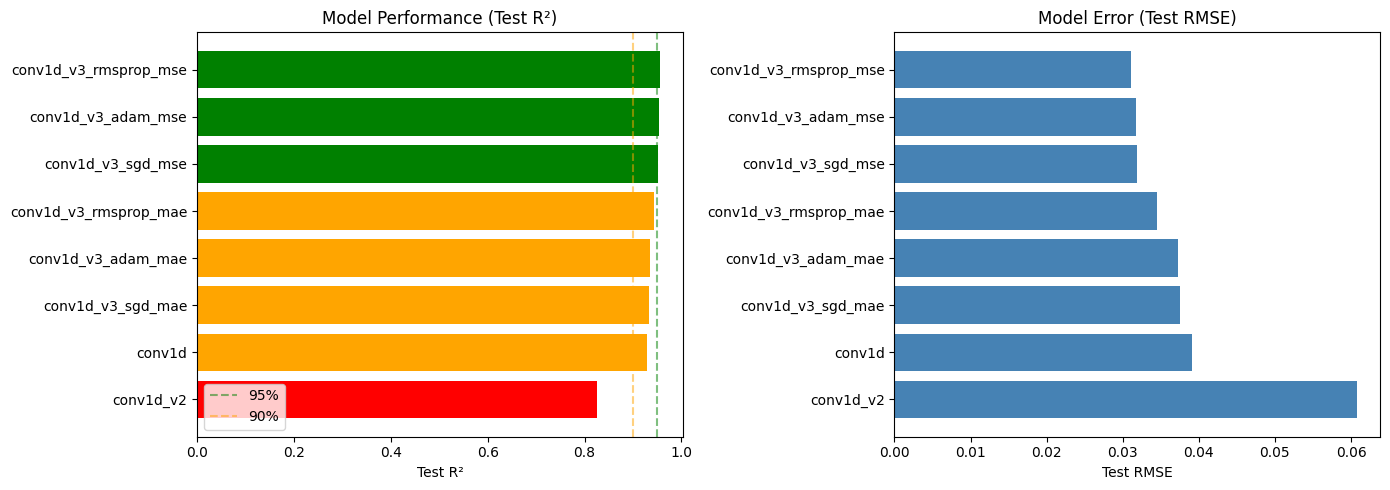

In [49]:
# Visualization
if 'df' in dir() and len(df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: R² comparison
    plot_df = df[df['test_r2'].notna()].sort_values('test_r2', ascending=True)
    colors = ['green' if r > 0.95 else 'orange' if r > 0.90 else 'red' for r in plot_df['test_r2']]
    axes[0].barh(plot_df['model'], plot_df['test_r2'], color=colors)
    axes[0].set_xlabel('Test R²')
    axes[0].set_title('Model Performance (Test R²)')
    axes[0].axvline(0.95, color='green', linestyle='--', alpha=0.5, label='95%')
    axes[0].axvline(0.90, color='orange', linestyle='--', alpha=0.5, label='90%')
    axes[0].legend()
    
    # Plot 2: RMSE comparison
    axes[1].barh(plot_df['model'], plot_df['test_rmse'], color='steelblue')
    axes[1].set_xlabel('Test RMSE')
    axes[1].set_title('Model Error (Test RMSE)')
    
    plt.tight_layout()
    plt.show()

## 6. Champion Model

### Conv1D_v3 + RMSprop + MSE

| Parameter | Value |
|-----------|-------|
| Architecture | Conv1D |
| Filters | (128, 256) |
| Kernel size | 3 |
| Pool size | 3 |
| Dense layers | (256, 128, 64) |
| Activation | ReLU |
| Dropout | 0.2 |
| Optimizer | RMSprop (lr=0.001) |
| Loss | MSE |
| Window size | 30 frames |
| Batch size | 32 |
| Epochs | 100 (early stopping) |

### Performance

| Metric | Validation | Test |
|--------|------------|------|
| R² | 0.9468 ± 0.0049 | **0.9549** |
| RMSE | 0.0335 ± 0.0018 | **0.0310** |
| MAE | 0.0241 ± 0.0013 | 0.0229 |

1. **Conv1D captures temporal patterns** - The 30-frame windows allow the model to learn motion dynamics
2. **Deeper architecture (v3)** - More filters and dense layers provide sufficient capacity
3. **RMSprop optimizer** - Adaptive learning rate works well with this data distribution
4. **MSE loss** - Better than MAE for regression with continuous targets

## 7. Dead Ends

### What Did NOT Work

| Configuration | R² | Issue |
|---------------|------|-------|
| LSTM | 0.77 | Overfitting, slow training |
| GRU | 0.74 | Similar to LSTM, underperformed |
| Dense MLP | 0.82 | Cannot capture temporal patterns |
| Conv1D_v2 (high dropout) | 0.83 | Too much regularization |
| MAE loss | ~0.93-0.94 | Lower R² than MSE |

## 8. Usage Guide

### Loading the Best Model

In [50]:
# Example: Load and use the best model
import tensorflow as tf
from tensorflow import keras

# Best model path
BEST_MODEL_PATH = 'cv_results_loss_optimizer/conv1d_v3_rmsprop_mse_fold4_best.h5'

if os.path.exists(BEST_MODEL_PATH):
    # Rebuild the model architecture and load weights (avoids Keras version mismatch)
    from models import build_conv1d_model
    model = build_conv1d_model(
        filters=(128, 256),
        kernel_size=3,
        pool_size=3,
        dense_units=(256, 128, 64),
        dropout_rate=0.2
    )
    model.load_weights(BEST_MODEL_PATH)
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    
    print(f"Model loaded from {BEST_MODEL_PATH}")
    model.summary()
else:
    print(f"Model not found at {BEST_MODEL_PATH}")

Model loaded from cv_results_loss_optimizer/conv1d_v3_rmsprop_mse_fold4_best.h5


Model: "Conv1DModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xy_seq_input (InputLayer)       │ (None, 30, 26)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv1D)                 │ (None, 30, 128)        │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling1D)           │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv_1 (Dropout)           │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv1D)                 │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling1D)           │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_conv_2 (Dropout)           │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_fc_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ z_output (Dense)                │ (None, 13)             │           845 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 216,461 (845.55 KB)

 Trainable params: 216,461 (845.55 KB)

 Non-trainable params: 0 (0.00 B)

In [51]:
# Example inference
def predict_z_coordinates(model, xy_sequence):
    """
    Predict Z coordinates from X/Y sequence.
    
    Args:
        model: Loaded Keras model
        xy_sequence: numpy array of shape (batch, 30, 26)
                     30 = window size, 26 = 13 joints × 2 (x, y)
    
    Returns:
        z_predictions: numpy array of shape (batch, 13)
                       13 z-coordinates for each joint
    """
    return model.predict(xy_sequence, verbose=0)

# Example with dummy data
if 'model' in dir():
    dummy_input = np.random.randn(1, 30, 26).astype(np.float32)
    z_pred = predict_z_coordinates(model, dummy_input)
    print(f"Input shape: {dummy_input.shape}")
    print(f"Output shape: {z_pred.shape}")
    print(f"Predicted Z values: {z_pred[0][:5]}...")

Input shape: (1, 30, 26)
Output shape: (1, 13)
Predicted Z values: [ 0.05649754  0.03968733 -0.03916807  0.05462698  0.00482728]...


### Retraining the Model

```bash
# Run the cross-validation training script
cd A9
python cv_training.py
```

Or modify `all_models_config.py` to change architecture parameters.